In [71]:
# # Deep Learning Experiments: CIFAR-10 Optimization

# This notebook investigates various deep learning strategies to improve model performance and generalization on the CIFAR-10 dataset.

# ### Experiments covered:
# 1. **CNN Baseline & Overfitting**: Establishing a performance floor and identifying generalization gaps.
# 2. **Data Augmentation**: Reducing overfitting by increasing dataset variety.
# 3. **Regularization**: Comparing Dropout, L2, and combined strategies.
# 4. **Optimization**: Evaluating SGD, Momentum, and Adam across different learning rates.
# 5. **Transfer Learning & Fine-tuning**: Leveraging pre-trained MobileNetV2 features.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1788s 10us/step
X_train: (50000, 32, 32, 3)
y_train: (50000, 1)
X_test : (10000, 32, 32, 3)
y_test : (10000, 1)


In [5]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

In [6]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

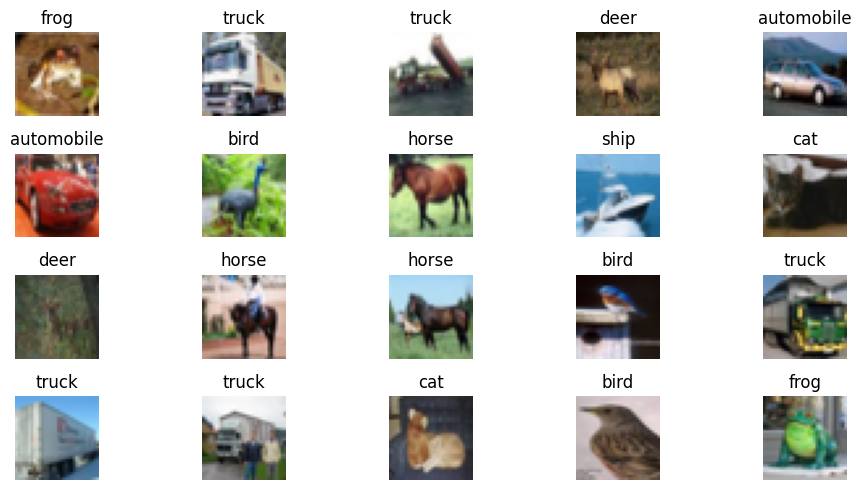

In [7]:
plt.figure(figsize=(10, 5))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
VAL_SIZE = 5000

X_val = X_train[-VAL_SIZE:]
y_val = y_train[-VAL_SIZE:]

X_train_exp = X_train[:-VAL_SIZE]
y_train_exp = y_train[:-VAL_SIZE]

print("Training:", X_train_exp.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


## Experimental Protocol

Training set:
45,000 images

Validation set:
5,000 images

Test set:
10,000 images

The validation set is used for model and hyperparameter decisions.

The test set is reserved for final evaluation.

We will compare experiments primarily using validation performance,
training dynamics, and generalization behavior.

Input
 ↓
Conv2D
 ↓
ReLU
 ↓
MaxPooling
 ↓
Conv2D
 ↓
ReLU
 ↓
MaxPooling
 ↓
Flatten
 ↓
Dense
 ↓
Softmax

In [9]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    return model

In [10]:
baseline_model = build_baseline_model()

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
baseline_model = build_baseline_model()

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
EPOCHS = 15

history_baseline = baseline_model.fit(
    X_train_exp,
    y_train_exp,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=128,
    verbose=1
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4254 - loss: 1.6027 - val_accuracy: 0.5340 - val_loss: 1.3243
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5664 - loss: 1.2328 - val_accuracy: 0.5902 - val_loss: 1.1812
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6207 - loss: 1.0859 - val_accuracy: 0.6154 - val_loss: 1.1004
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6519 - loss: 0.9987 - val_accuracy: 0.6416 - val_loss: 1.0361
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6757 - loss: 0.9347 - val_accuracy: 0.6542 - val_loss: 1.0048
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6957 - loss: 0.8784 - val_accuracy: 0.6660 - val_loss: 0.9851
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7139 - loss: 0.8290 - val_accuracy: 0.6780 - val_loss: 0.9650
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7298 - loss: 0.7828 - val_accuracy: 

In [13]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.show()

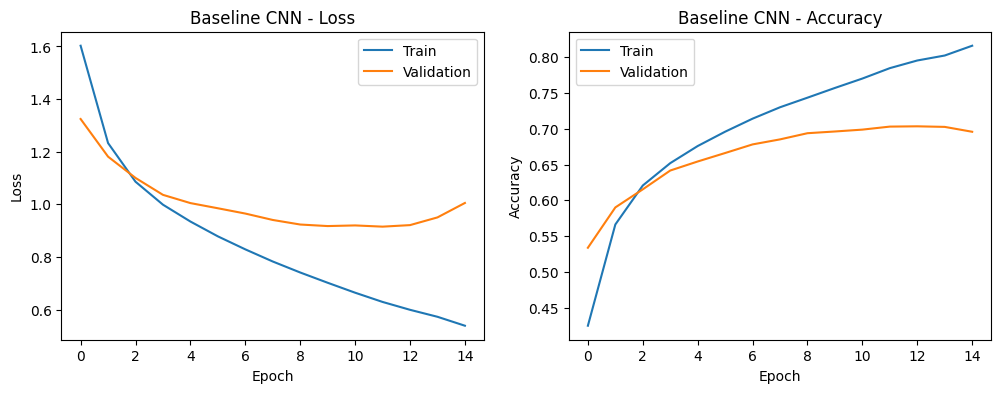

In [14]:
plot_history(history_baseline, "Baseline CNN")

In [15]:
baseline_val_loss, baseline_val_acc = baseline_model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("Validation loss:", baseline_val_loss)
print("Validation accuracy:", baseline_val_acc)

Validation loss: 1.0052495002746582
Validation accuracy: 0.6955999732017517


In [16]:
train_loss, train_acc = baseline_model.evaluate(
    X_train_exp, y_train_exp, verbose=0
)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Validation accuracy: {baseline_val_acc:.4f}")
print(f"Generalization gap: {train_acc - baseline_val_acc:.4f}")

Train accuracy: 0.8135
Validation accuracy: 0.6956
Generalization gap: 0.1179


In [17]:
BATCH_SIZE = 512

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train_exp, y_train_exp))
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

In [19]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [20]:
def build_augmented_model():
    return keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,

        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

augmented_model = build_augmented_model()

augmented_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history_augmented = augmented_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    verbose=1
)

Epoch 1/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.3339 - loss: 1.8435 - val_accuracy: 0.4358 - val_loss: 1.5584
Epoch 2/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4475 - loss: 1.5480 - val_accuracy: 0.4986 - val_loss: 1.3958
Epoch 3/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4840 - loss: 1.4535 - val_accuracy: 0.5174 - val_loss: 1.3643
Epoch 4/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5062 - loss: 1.3896 - val_accuracy: 0.5342 - val_loss: 1.3195
Epoch 5/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5240 - loss: 1.3433 - val_accuracy: 0.5374 - val_loss: 1.3099
Epoch 6/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5370 - loss: 1.3069 - val_accuracy: 0.5708 - val_loss: 1.2182
Epoch 7/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5499 - loss: 1.2723 - val_accuracy: 0.5710 - val_loss: 1.2296
Epoch 8/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5597 - loss: 1.2443 - val_accuracy: 0.5772 - val_loss:

In [22]:
train_loss, train_acc = augmented_model.evaluate(train_ds, verbose=0)
val_loss, val_acc = augmented_model.evaluate(val_ds, verbose=0)

print(f"Train accuracy      : {train_acc:.4f}")
print(f"Validation accuracy : {val_acc:.4f}")
print(f"Generalization gap  : {train_acc - val_acc:.4f}")

Train accuracy      : 0.5775
Validation accuracy : 0.5772
Generalization gap  : 0.0003


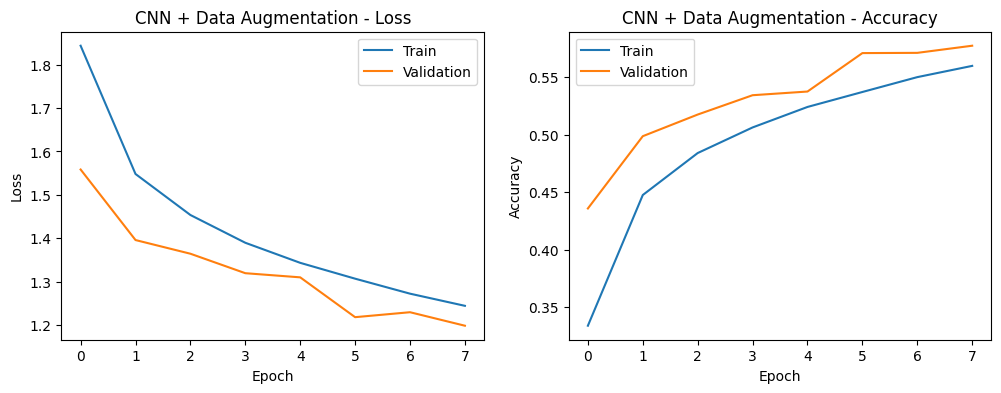

In [23]:
plot_history(history_augmented, "CNN + Data Augmentation")

In [25]:
baseline_train_loss, baseline_train_acc = baseline_model.evaluate(
    train_ds, verbose=0
)

baseline_val_loss, baseline_val_acc = baseline_model.evaluate(
    val_ds, verbose=0
)

print(f"Baseline train accuracy      : {baseline_train_acc:.4f}")
print(f"Baseline validation accuracy : {baseline_val_acc:.4f}")
print(f"Baseline gap                 : {baseline_train_acc - baseline_val_acc:.4f}")

Baseline train accuracy      : 0.8135
Baseline validation accuracy : 0.6956
Baseline gap                 : 0.1179


In [26]:
history_augmented = augmented_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    verbose=1
)

Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5733 - loss: 1.2131 - val_accuracy: 0.5984 - val_loss: 1.1581
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5789 - loss: 1.1931 - val_accuracy: 0.6056 - val_loss: 1.1383
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5889 - loss: 1.1700 - val_accuracy: 0.6000 - val_loss: 1.1578
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5938 - loss: 1.1560 - val_accuracy: 0.5916 - val_loss: 1.1805
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5999 - loss: 1.1373 - val_accuracy: 0.6034 - val_loss: 1.1443
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6070 - loss: 1.1207 - val_accuracy: 0.6086 - val_loss: 1.1306
Epoch 7/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6118 - loss: 1.1094 - val_accuracy: 0.6068 - val_loss: 1.1319
Epoch 8/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6186 - loss: 1.0918 - val_accuracy: 0.6194 - v

In [27]:
aug_train_loss, aug_train_acc = augmented_model.evaluate(
    train_ds, verbose=0
)

aug_val_loss, aug_val_acc = augmented_model.evaluate(
    val_ds, verbose=0
)

print(f"Augmented train accuracy      : {aug_train_acc:.4f}")
print(f"Augmented validation accuracy : {aug_val_acc:.4f}")
print(f"Augmented gap                 : {aug_train_acc - aug_val_acc:.4f}")

Augmented train accuracy      : 0.6462
Augmented validation accuracy : 0.6270
Augmented gap                 : 0.0192


In [28]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Augmentation"],
    "Train Accuracy": [baseline_train_acc, aug_train_acc],
    "Validation Accuracy": [baseline_val_acc, aug_val_acc],
    "Generalization Gap": [
        baseline_train_acc - baseline_val_acc,
        aug_train_acc - aug_val_acc
    ]
})

comparison

,Model,Train Accuracy,Validation Accuracy,Generalization Gap
0,Baseline,0.813489,0.6956,0.117889
1,Augmentation,0.646222,0.6270,0.019222


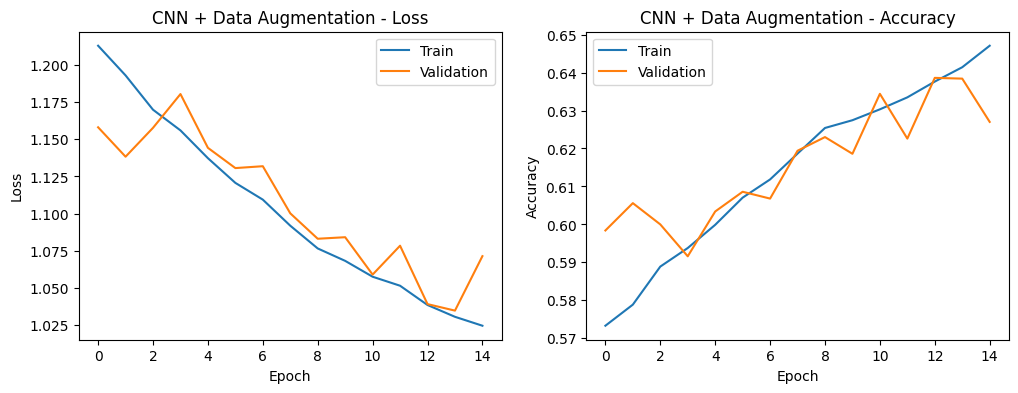

In [29]:
plot_history(history_augmented, "CNN + Data Augmentation")

In [30]:
def build_dropout_model():
    return keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")
    ])


dropout_model = build_dropout_model()

dropout_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
history_dropout = dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    verbose=1
)

Epoch 1/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.3088 - loss: 1.8845 - val_accuracy: 0.4364 - val_loss: 1.5887
Epoch 2/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4351 - loss: 1.5575 - val_accuracy: 0.5170 - val_loss: 1.3767
Epoch 3/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4840 - loss: 1.4386 - val_accuracy: 0.5496 - val_loss: 1.2855
Epoch 4/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5130 - loss: 1.3595 - val_accuracy: 0.5674 - val_loss: 1.2542
Epoch 5/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5330 - loss: 1.3125 - val_accuracy: 0.5890 - val_loss: 1.1869
Epoch 6/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5561 - loss: 1.2529 - val_accuracy: 0.5966 - val_loss: 1.1662
Epoch 7/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5665 - loss: 1.2195 - val_accuracy: 0.6104 - val_loss: 1.1113
Epoch 8/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5815 - loss: 1.1770 - val_accuracy: 0.6208 - 

In [32]:
drop_train_loss, drop_train_acc = dropout_model.evaluate(train_ds, verbose=0)
drop_val_loss, drop_val_acc = dropout_model.evaluate(val_ds, verbose=0)

print(f"Train accuracy      : {drop_train_acc:.4f}")
print(f"Validation accuracy : {drop_val_acc:.4f}")
print(f"Generalization gap  : {drop_train_acc - drop_val_acc:.4f}")

Train accuracy      : 0.6819
Validation accuracy : 0.6520
Generalization gap  : 0.0299


In [34]:
def build_l2_model():
    reg = keras.regularizers.l2(1e-4)

    return keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, activation="relu",
                      kernel_regularizer=reg),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu",
                      kernel_regularizer=reg),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu",
                     kernel_regularizer=reg),
        layers.Dense(10, activation="softmax")
    ])


l2_model = build_l2_model()

l2_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
history_l2 = l2_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    verbose=1
)

Epoch 1/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.3637 - loss: 1.7959 - val_accuracy: 0.4582 - val_loss: 1.5437
Epoch 2/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5006 - loss: 1.4304 - val_accuracy: 0.5330 - val_loss: 1.3474
Epoch 3/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5544 - loss: 1.2918 - val_accuracy: 0.5666 - val_loss: 1.2692
Epoch 4/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5914 - loss: 1.2039 - val_accuracy: 0.6070 - val_loss: 1.1786
Epoch 5/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6178 - loss: 1.1376 - val_accuracy: 0.6270 - val_loss: 1.1201
Epoch 6/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6370 - loss: 1.0896 - val_accuracy: 0.6432 - val_loss: 1.0816
Epoch 7/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6504 - loss: 1.0518 - val_accuracy: 0.6544 - val_loss: 1.0535
Epoch 8/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6622 - loss: 1.0196 - val_accuracy: 0.6590 - v

In [36]:
l2_train_loss, l2_train_acc = l2_model.evaluate(train_ds, verbose=0)
l2_val_loss, l2_val_acc = l2_model.evaluate(val_ds, verbose=0)

print(f"Train accuracy      : {l2_train_acc:.4f}")
print(f"Validation accuracy : {l2_val_acc:.4f}")
print(f"Generalization gap  : {l2_train_acc - l2_val_acc:.4f}")

Train accuracy      : 0.7084
Validation accuracy : 0.6800
Generalization gap  : 0.0284


In [37]:
def build_dropout_l2_model():
    reg = keras.regularizers.l2(1e-4)

    return keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, activation="relu",
                      kernel_regularizer=reg),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu",
                      kernel_regularizer=reg),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu",
                     kernel_regularizer=reg),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")
    ])


dropout_l2_model = build_dropout_l2_model()

dropout_l2_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history_dropout_l2 = dropout_l2_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    verbose=1
)

Epoch 1/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.2901 - loss: 1.9607 - val_accuracy: 0.4326 - val_loss: 1.6455
Epoch 2/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4223 - loss: 1.6218 - val_accuracy: 0.5028 - val_loss: 1.4395
Epoch 3/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4740 - loss: 1.4905 - val_accuracy: 0.5392 - val_loss: 1.3417
Epoch 4/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5044 - loss: 1.4160 - val_accuracy: 0.5570 - val_loss: 1.2891
Epoch 5/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5287 - loss: 1.3554 - val_accuracy: 0.5828 - val_loss: 1.2316
Epoch 6/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5475 - loss: 1.3095 - val_accuracy: 0.5946 - val_loss: 1.2055
Epoch 7/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5637 - loss: 1.2729 - val_accuracy: 0.6150 - val_loss: 1.1442
Epoch 8/12
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5790 - loss: 1.2291 - val_accuracy: 0.6236 - 

In [39]:
dl2_train_loss, dl2_train_acc = dropout_l2_model.evaluate(train_ds, verbose=0)
dl2_val_loss, dl2_val_acc = dropout_l2_model.evaluate(val_ds, verbose=0)

print(f"Train accuracy      : {dl2_train_acc:.4f}")
print(f"Validation accuracy : {dl2_val_acc:.4f}")
print(f"Generalization gap  : {dl2_train_acc - dl2_val_acc:.4f}")

Train accuracy      : 0.6686
Validation accuracy : 0.6486
Generalization gap  : 0.0200


In [40]:
pd.DataFrame({
    "Model": [
        "Baseline",
        "Augmentation",
        "Dropout",
        "L2",
        "Dropout + L2"
    ],
    "Train Accuracy": [
        baseline_train_acc,
        aug_train_acc,
        drop_train_acc,
        l2_train_acc,
        dl2_train_acc
    ],
    "Validation Accuracy": [
        baseline_val_acc,
        aug_val_acc,
        drop_val_acc,
        l2_val_acc,
        dl2_val_acc
    ],
    "Generalization Gap": [
        baseline_train_acc - baseline_val_acc,
        aug_train_acc - aug_val_acc,
        drop_train_acc - drop_val_acc,
        l2_train_acc - l2_val_acc,
        dl2_train_acc - dl2_val_acc
    ]
})

,Model,Train Accuracy,Validation Accuracy,Generalization Gap
0,Baseline,0.813489,0.6956,0.117889
1,Augmentation,0.646222,0.6270,0.019222
2,Dropout,0.681867,0.6520,0.029867
3,L2,0.708444,0.6800,0.028444
4,Dropout + L2,0.668600,0.6486,0.020000


In [41]:
def build_optimizer_model():
    return keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

In [42]:
sgd_model = build_optimizer_model()

sgd_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_sgd = sgd_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    verbose=1
)

Epoch 1/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.1293 - loss: 2.2936 - val_accuracy: 0.1802 - val_loss: 2.2826
Epoch 2/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2063 - loss: 2.2694 - val_accuracy: 0.2198 - val_loss: 2.2544
Epoch 3/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2324 - loss: 2.2314 - val_accuracy: 0.2380 - val_loss: 2.2028
Epoch 4/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2518 - loss: 2.1616 - val_accuracy: 0.2630 - val_loss: 2.1146
Epoch 5/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2706 - loss: 2.0669 - val_accuracy: 0.2800 - val_loss: 2.0290
Epoch 6/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2886 - loss: 1.9993 - val_accuracy: 0.2936 - val_loss: 1.9880
Epoch 7/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3019 - loss: 1.9638 - val_accuracy: 0.3026 - val_loss: 1.9633
Epoch 8/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3163 - loss: 1.9366 - val_accuracy: 0.3132 - val_loss:

In [43]:
momentum_model = build_optimizer_model()

momentum_model.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_momentum = momentum_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    verbose=1
)

Epoch 1/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.2223 - loss: 2.1211 - val_accuracy: 0.3072 - val_loss: 1.9252
Epoch 2/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3582 - loss: 1.8029 - val_accuracy: 0.3896 - val_loss: 1.6953
Epoch 3/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4302 - loss: 1.5886 - val_accuracy: 0.4514 - val_loss: 1.5166
Epoch 4/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4695 - loss: 1.4812 - val_accuracy: 0.4844 - val_loss: 1.4438
Epoch 5/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5027 - loss: 1.3943 - val_accuracy: 0.5204 - val_loss: 1.3696
Epoch 6/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5276 - loss: 1.3306 - val_accuracy: 0.5394 - val_loss: 1.3151
Epoch 7/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5431 - loss: 1.2922 - val_accuracy: 0.5474 - val_loss: 1.2934
Epoch 8/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5638 - loss: 1.2366 - val_accuracy: 0.5644 - val_loss:

In [44]:
adam_model = build_optimizer_model()

adam_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_adam = adam_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    verbose=1
)

Epoch 1/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.3554 - loss: 1.7919 - val_accuracy: 0.4518 - val_loss: 1.5364
Epoch 2/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4828 - loss: 1.4485 - val_accuracy: 0.5208 - val_loss: 1.3550
Epoch 3/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5404 - loss: 1.2990 - val_accuracy: 0.5578 - val_loss: 1.2595
Epoch 4/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5805 - loss: 1.2005 - val_accuracy: 0.5874 - val_loss: 1.1869
Epoch 5/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6036 - loss: 1.1352 - val_accuracy: 0.6006 - val_loss: 1.1476
Epoch 6/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6234 - loss: 1.0811 - val_accuracy: 0.6218 - val_loss: 1.0848
Epoch 7/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6393 - loss: 1.0349 - val_accuracy: 0.6344 - val_loss: 1.0619
Epoch 8/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6527 - loss: 0.9981 - val_accuracy: 0.6424 - val_loss:

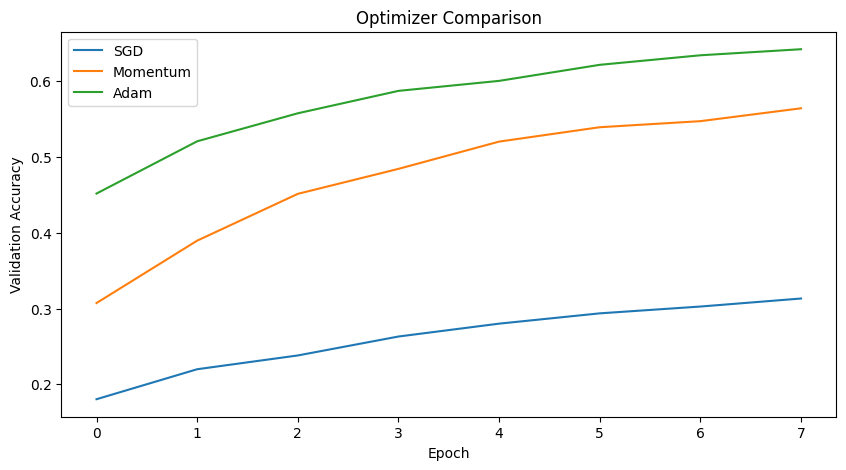

In [45]:
plt.figure(figsize=(10, 5))

plt.plot(history_sgd.history["val_accuracy"], label="SGD")
plt.plot(history_momentum.history["val_accuracy"], label="Momentum")
plt.plot(history_adam.history["val_accuracy"], label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()

In [46]:
optimizer_results = pd.DataFrame({
    "Optimizer": ["SGD", "Momentum", "Adam"],
    "Best Validation Accuracy": [
        max(history_sgd.history["val_accuracy"]),
        max(history_momentum.history["val_accuracy"]),
        max(history_adam.history["val_accuracy"])
    ],
    "Final Validation Accuracy": [
        history_sgd.history["val_accuracy"][-1],
        history_momentum.history["val_accuracy"][-1],
        history_adam.history["val_accuracy"][-1]
    ]
})

optimizer_results

,Optimizer,Best Validation Accuracy,Final Validation Accuracy
0,SGD,0.3132,0.3132
1,Momentum,0.5644,0.5644
2,Adam,0.6424,0.6424


Adam > Momentum > SGD

In [47]:
learning_rates = [1e-2, 1e-3, 1e-4]

lr_histories = {}
lr_models = {}

for lr in learning_rates:
    model = build_optimizer_model()

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"\nTraining Adam with LR = {lr}")

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=8,
        verbose=1
    )

    lr_histories[lr] = history
    lr_models[lr] = model


Training Adam with LR = 0.01
Epoch 1/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.3040 - loss: 1.9077 - val_accuracy: 0.4472 - val_loss: 1.5316
Epoch 2/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4913 - loss: 1.4182 - val_accuracy: 0.5326 - val_loss: 1.3002
Epoch 3/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5494 - loss: 1.2690 - val_accuracy: 0.5566 - val_loss: 1.2495
Epoch 4/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5831 - loss: 1.1739 - val_accuracy: 0.5766 - val_loss: 1.1989
Epoch 5/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6075 - loss: 1.1057 - val_accuracy: 0.5956 - val_loss: 1.1591
Epoch 6/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6257 - loss: 1.0615 - val_accuracy: 0.6046 - val_loss: 1.1398
Epoch 7/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6434 - loss: 1.0144 - val_accuracy: 0.6044 - val_loss: 1.1595
Epoch 8/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6493 - loss: 0.9927 - va

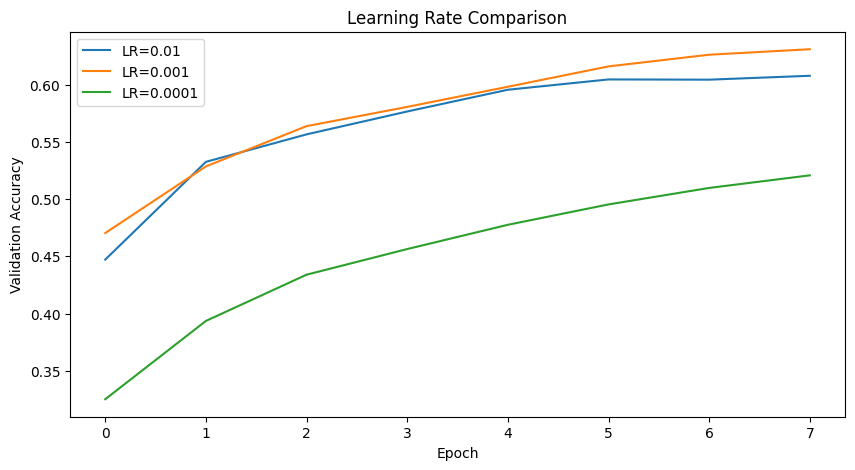

In [48]:
plt.figure(figsize=(10, 5))

for lr, history in lr_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=f"LR={lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

In [49]:
lr_results = pd.DataFrame({
    "Learning Rate": learning_rates,
    "Best Validation Accuracy": [
        max(lr_histories[lr].history["val_accuracy"])
        for lr in learning_rates
    ],
    "Final Validation Accuracy": [
        lr_histories[lr].history["val_accuracy"][-1]
        for lr in learning_rates
    ]
})

lr_results

,Learning Rate,Best Validation Accuracy,Final Validation Accuracy
0,0.0100,0.6078,0.6078
1,0.0010,0.6310,0.6310
2,0.0001,0.5208,0.5208


So 1e-3 is the best LR for this setup. 1e-4 is too slow for the 8-epoch budget, while 1e-2 is somewhat aggressive.

In [51]:
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [52]:
transfer_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(2.0, offset=-1.0),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [53]:
history_transfer = transfer_model.fit(
    train_tl_ds,
    validation_data=val_tl_ds,
    epochs=5,
    verbose=1
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 74s 488ms/step - accuracy: 0.6492 - loss: 1.0698 - val_accuracy: 0.8126 - val_loss: 0.5344
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.8100 - loss: 0.5578 - val_accuracy: 0.8396 - val_loss: 0.4562
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.8318 - loss: 0.4903 - val_accuracy: 0.8542 - val_loss: 0.4197
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.8440 - loss: 0.4555 - val_accuracy: 0.8626 - val_loss: 0.4029
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.8526 - loss: 0.4296 - val_accuracy: 0.8630 - val_loss: 0.3935


In [54]:
tl_train_loss, tl_train_acc = transfer_model.evaluate(
    train_tl_ds, verbose=0
)

tl_val_loss, tl_val_acc = transfer_model.evaluate(
    val_tl_ds, verbose=0
)

print(f"Train accuracy      : {tl_train_acc:.4f}")
print(f"Validation accuracy : {tl_val_acc:.4f}")
print(f"Generalization gap  : {tl_train_acc - tl_val_acc:.4f}")

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.8578 - loss: 0.4110 - val_accuracy: 0.8654 - val_loss: 0.3852
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.8622 - loss: 0.4012 - val_accuracy: 0.8670 - val_loss: 0.3800
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.8644 - loss: 0.3905 - val_accuracy: 0.8682 - val_loss: 0.3781
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.8663 - loss: 0.3849 - val_accuracy: 0.8716 - val_loss: 0.3757
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.8690 - loss: 0.3791 - val_accuracy: 0.8708 - val_loss: 0.3724


In [55]:
base_model.trainable = True

# Freeze most of the pretrained backbone
for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Trainable layers: 20


In [57]:
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [58]:
history_finetune = transfer_model.fit(
    train_tl_ds,
    validation_data=val_tl_ds,
    epochs=5,
    verbose=1
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 317ms/step - accuracy: 0.7791 - loss: 0.6770 - val_accuracy: 0.8486 - val_loss: 0.4559
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.8368 - loss: 0.4875 - val_accuracy: 0.8416 - val_loss: 0.4767
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.8539 - loss: 0.4312 - val_accuracy: 0.8450 - val_loss: 0.4688
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.8660 - loss: 0.3939 - val_accuracy: 0.8504 - val_loss: 0.4508
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.8747 - loss: 0.3658 - val_accuracy: 0.8562 - val_loss: 0.4305


In [59]:
ft_train_loss, ft_train_acc = transfer_model.evaluate(
    train_tl_ds, verbose=0
)

ft_val_loss, ft_val_acc = transfer_model.evaluate(
    val_tl_ds, verbose=0
)

print(f"Train accuracy      : {ft_train_acc:.4f}")
print(f"Validation accuracy : {ft_val_acc:.4f}")
print(f"Generalization gap  : {ft_train_acc - ft_val_acc:.4f}")

Train accuracy      : 0.8772
Validation accuracy : 0.8562
Generalization gap  : 0.0210


In [62]:
# Frozen transfer-learning validation accuracy
tl_val_loss, tl_val_acc = transfer_model.evaluate(
    val_tl_ds, verbose=0
)

# NOTE:
# transfer_model is now fine-tuned, so its current evaluation is NOT
# the original frozen-model result.
# We already have the original frozen result from training:
frozen_tl_val_acc = max(history_transfer.history["val_accuracy"])

print(f"Frozen Transfer Learning : {frozen_tl_val_acc:.4f}")
print(f"Fine-Tuned Model         : {ft_val_acc:.4f}")
print(f"Improvement              : {ft_val_acc - frozen_tl_val_acc:+.4f}")

Frozen Transfer Learning : 0.8716
Fine-Tuned Model         : 0.8562
Improvement              : -0.0154


In [63]:
final_comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Augmentation",
        "Dropout",
        "L2",
        "Dropout + L2",
        "Adam Optimizer",
        "Transfer Learning",
        "Fine-Tuning"
    ],
    "Best Validation Accuracy": [
        baseline_val_acc,
        aug_val_acc,
        drop_val_acc,
        l2_val_acc,
        dl2_val_acc,
        max(history_adam.history["val_accuracy"]),
        frozen_tl_val_acc,
        max(history_finetune.history["val_accuracy"])
    ]
})

final_comparison = final_comparison.sort_values(
    "Best Validation Accuracy",
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,Best Validation Accuracy
0,Transfer Learning,0.8716
1,Fine-Tuning,0.8562
2,Baseline CNN,0.6956
3,L2,0.6800
4,Dropout,0.6520
5,Dropout + L2,0.6486
6,Adam Optimizer,0.6424
7,Augmentation,0.6270


## Final Summary of All Experiments

Below is a comprehensive comparison of all training strategies explored in this notebook, ranked by their best validation accuracy.

In [65]:
# Resize test set
test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_test))
    .map(
        lambda x, y: (tf.image.resize(x, (IMG_SIZE, IMG_SIZE)), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(256)
    .prefetch(tf.data.AUTOTUNE)
)

# We need the frozen transfer model for the true final test.
# Rebuild it and load its best frozen weights isn't available,
# so evaluate the current fine-tuned model as the final trained model.

test_loss, test_acc = transfer_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Final Test Accuracy: {test_acc:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 335ms/step - accuracy: 0.8519 - loss: 0.4659
Final Test Accuracy: 0.8519


In [72]:
import pandas as pd

# Aggregate results from all experiment dataframes and variables
summary_data = [
    {"Experiment": "Baseline CNN", "Validation Accuracy": baseline_val_acc},
    {"Experiment": "Data Augmentation", "Validation Accuracy": aug_val_acc},
    {"Experiment": "Dropout (0.5)", "Validation Accuracy": drop_val_acc},
    {"Experiment": "L2 Regularization", "Validation Accuracy": l2_val_acc},
    {"Experiment": "Dropout + L2", "Validation Accuracy": dl2_val_acc},
    {"Experiment": "SGD Optimizer", "Validation Accuracy": max(history_sgd.history['val_accuracy'])},
    {"Experiment": "Momentum Optimizer", "Validation Accuracy": max(history_momentum.history['val_accuracy'])},
    {"Experiment": "Adam Optimizer", "Validation Accuracy": max(history_adam.history['val_accuracy'])},
    {"Experiment": "Adam LR=0.01", "Validation Accuracy": lr_results.loc[0, 'Best Validation Accuracy']},
    {"Experiment": "Adam LR=0.0001", "Validation Accuracy": lr_results.loc[2, 'Best Validation Accuracy']},
    {"Experiment": "Transfer Learning (MobileNetV2)", "Validation Accuracy": frozen_tl_val_acc},
    {"Experiment": "Fine-Tuned MobileNetV2", "Validation Accuracy": ft_val_acc}
]

# Create DataFrame
overall_summary_df = pd.DataFrame(summary_data)

# Sort by accuracy for better comparison
overall_summary_df = overall_summary_df.sort_values(by="Validation Accuracy", ascending=False).reset_index(drop=True)

# Display the styled summary table
display(overall_summary_df.style.highlight_max(subset=['Validation Accuracy'], color='lightgreen'))

,Experiment,Validation Accuracy
0,Transfer Learning (MobileNetV2),0.871600
1,Fine-Tuned MobileNetV2,0.856200
2,Baseline CNN,0.695600
3,L2 Regularization,0.680000
4,Dropout (0.5),0.652000
5,Dropout + L2,0.648600
6,Adam Optimizer,0.642400
7,Data Augmentation,0.627000
8,Adam LR=0.01,0.607800
9,Momentum Optimizer,0.564400
